In [2]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# =========================
# LOAD DATA
# =========================
dataset = pd.read_csv("cars_fuel_efficiency_clean.csv")

print("Data Set (first 10 rows):")
print(dataset.head(10))
print("\nDataset Shape:", dataset.shape)
print("\nColumn Names:", dataset.columns.tolist())

Data Set (first 10 rows):
   trip_id       car_name vehicle_type fuel_type        trip_category  \
0        1       Lexus ES       Luxury    Diesel  Very Long (>400 km)   
1        2       Lexus ES       Luxury    Petrol   Medium (50–200 km)   
2        3        Audi A6       Luxury    Petrol   Medium (50–200 km)   
3        4   Maruti Swift    Hatchback    Diesel    Long (200–400 km)   
4        5  Hyundai Creta          SUV    Diesel    Long (200–400 km)   
5        6   BMW 5 Series       Luxury    Petrol    Long (200–400 km)   
6        7   BMW 5 Series       Luxury    Hybrid  Very Long (>400 km)   
7        8    Hyundai i20    Hatchback    Diesel   Medium (50–200 km)   
8        9   Maruti Swift    Hatchback    Hybrid  Very Long (>400 km)   
9       10  Maruti Ertiga          MUV    Diesel   Medium (50–200 km)   

   distance_km  trip_duration_hr  avg_speed_kmph  base_mileage_kmpl  \
0       437.85              4.84           90.51              11.31   
1       181.86              

In [4]:
# =========================
# CLEANING
# =========================
print(dataset.isnull().sum())

dataset = dataset.fillna(dataset.mean(numeric_only=True))
dataset = dataset.drop_duplicates()

trip_id                0
car_name               0
vehicle_type           0
fuel_type              0
trip_category          0
distance_km            0
trip_duration_hr       0
avg_speed_kmph         0
base_mileage_kmpl      0
actual_mileage_kmpl    0
mileage_delta_kmpl     0
fuel_consumed_L        0
fuel_cost_usd          0
cost_per_km_usd        0
co2_emissions_kg       0
co2_per_km             0
relative_efficiency    0
efficiency_band        0
dtype: int64


In [5]:
# =========================
# ENCODING
# =========================
dataset = pd.get_dummies(dataset, drop_first=True)

print("Updated Columns After Encoding:")
print(dataset.columns.tolist())

Updated Columns After Encoding:
['trip_id', 'distance_km', 'trip_duration_hr', 'avg_speed_kmph', 'base_mileage_kmpl', 'actual_mileage_kmpl', 'mileage_delta_kmpl', 'fuel_consumed_L', 'fuel_cost_usd', 'cost_per_km_usd', 'co2_emissions_kg', 'co2_per_km', 'relative_efficiency', 'car_name_BMW 5 Series', 'car_name_Honda Brio', 'car_name_Honda City', 'car_name_Hyundai Creta', 'car_name_Hyundai Verna', 'car_name_Hyundai i20', 'car_name_Jaguar XF', 'car_name_Kia Carens', 'car_name_Kia Seltos', 'car_name_Lexus ES', 'car_name_MG Hector', 'car_name_Mahindra Marazzo', 'car_name_Maruti Alto', 'car_name_Maruti Ciaz', 'car_name_Maruti Ertiga', 'car_name_Maruti Swift', 'car_name_Mercedes C-Class', 'car_name_Renault Triber', 'car_name_Skoda Rapid', 'car_name_Tata Harrier', 'car_name_Tata Tiago', 'car_name_Toyota Fortuner', 'car_name_Toyota Innova', 'car_name_Toyota Yaris', 'vehicle_type_Luxury', 'vehicle_type_MUV', 'vehicle_type_SUV', 'vehicle_type_Sedan', 'fuel_type_Hybrid', 'fuel_type_Petrol', 'trip_c

In [6]:
# =========================
# TRAIN TEST SPLIT
# =========================
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("X_train sample:")
print(X_train.head())

print("\ny_train sample:")
print(y_train.head())

X_train sample:
     trip_id  distance_km  trip_duration_hr  avg_speed_kmph  \
563      564       393.60              3.41          115.30   
339      340       109.00              2.00           54.57   
360      361       165.98              1.85           89.69   
256      257        83.49              1.50           55.74   
61        62       244.67              3.17           77.30   

     base_mileage_kmpl  actual_mileage_kmpl  mileage_delta_kmpl  \
563              16.65                15.52               -1.13   
339              19.04                18.99               -0.05   
360              19.34                20.14                0.80   
256              19.07                20.12                1.05   
61               15.14                14.39               -0.75   

     fuel_consumed_L  fuel_cost_usd  cost_per_km_usd  ...  vehicle_type_MUV  \
563            25.36          29.03           0.0738  ...              True   
339             5.74           6.57         

In [7]:
# =========================
# SCALING
# =========================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

scaled_df = pd.DataFrame(X_train, columns=dataset.columns[:-1])

print("Scaled Data:")
print(scaled_df.head())

Scaled Data:
    trip_id  distance_km  trip_duration_hr  avg_speed_kmph  base_mileage_kmpl  \
0  1.475612     1.007843         -0.077188        1.600421           0.225245   
1  0.203796    -1.088455         -0.685697       -1.049997           0.871152   
2  0.323029    -0.668754         -0.750432        0.482733           0.952228   
3 -0.267458    -1.276356         -0.901481       -0.998935           0.879259   
4 -1.374619    -0.089141         -0.180764       -0.057999          -0.182838   

   actual_mileage_kmpl  mileage_delta_kmpl  fuel_consumed_L  fuel_cost_usd  \
0            -0.095680           -1.315560         0.805896       0.662420   
1             0.807955           -0.132419        -1.124201      -1.138436   
2             1.107430            0.798757        -0.878266      -0.829741   
3             1.102222            1.072632        -1.280616      -1.284365   
4            -0.389948           -0.899269        -0.016510      -0.104908   

   cost_per_km_usd  ...  vehicl

In [8]:
# =========================
# DESCRIPTIVE FUNCTION
# =========================
def Desc_stat(ds,var):

    mean=ds[var].mean()
    median=ds[var].median()
    mode=ds[var].mode()[0]
    minimum=ds[var].min()
    maximum=ds[var].max()
    data_range=maximum - minimum
    std_dev=ds[var].std()
    variance=ds[var].var()
    skew=ds[var].skew()
    kurtosis=ds[var].kurt()
    count=ds[var].count()

    Quart = [
        ds[var].quantile(0),
        ds[var].quantile(0.25),
        ds[var].quantile(0.50),
        ds[var].quantile(0.75),
        ds[var].quantile(1),
        ds[var].quantile(0.75) - ds[var].quantile(0.25)
    ]

    summary = {
        "Mean": mean,
        "Median": median,
        "Mode": mode,
        "Minimum": minimum,
        "Maximum": maximum,
        "Range": data_range,
        "Std Dev": std_dev,
        "Variance": variance,
        "Skewness": skew,
        "Kurtosis": kurtosis,
        "0% (Min)": Quart[0],
        "25th Percentile": Quart[1],
        "50th Percentile": Quart[2],
        "75th Percentile": Quart[3],
        "100% (Max)": Quart[4],
        "Inter Quartile Range": Quart[5],
        "Count": count
    }

    return summary

Desc_stat(dataset, "actual_mileage_kmpl")

{'Mean': 15.938833333333331,
 'Median': 15.48,
 'Mode': 15.72,
 'Minimum': 7.38,
 'Maximum': 27.37,
 'Range': 19.990000000000002,
 'Std Dev': 3.8667439126953,
 'Variance': 14.951708486366158,
 'Skewness': 0.4184695395927481,
 'Kurtosis': -0.26546629622446316,
 '0% (Min)': 7.38,
 '25th Percentile': 12.96,
 '50th Percentile': 15.48,
 '75th Percentile': 18.572499999999998,
 '100% (Max)': 27.37,
 'Inter Quartile Range': 5.612499999999997,
 'Count': 600}

In [9]:
# =========================
# RANDOM SAMPLING
# =========================
random_sample = dataset.sample(n=150, random_state=42)
Desc_stat(random_sample, "actual_mileage_kmpl")

{'Mean': 15.087333333333335,
 'Median': 14.96,
 'Mode': 10.86,
 'Minimum': 7.57,
 'Maximum': 27.37,
 'Range': 19.8,
 'Std Dev': 3.6277692346243313,
 'Variance': 13.160709619686807,
 'Skewness': 0.35068927024304714,
 'Kurtosis': -0.04023020673095745,
 '0% (Min)': 7.57,
 '25th Percentile': 12.412500000000001,
 '50th Percentile': 14.96,
 '75th Percentile': 17.53,
 '100% (Max)': 27.37,
 'Inter Quartile Range': 5.1175,
 'Count': 150}

In [10]:
# =========================
# SYSTEMATIC SAMPLING
# =========================
dataset.columns = dataset.columns.str.strip()

sample_size = 150
k = len(dataset) // sample_size

systematic_sample = dataset.iloc[::k]
systematic_sample = systematic_sample.head(150)

systematic_sample.head()

,trip_id,distance_km,trip_duration_hr,avg_speed_kmph,base_mileage_kmpl,actual_mileage_kmpl,mileage_delta_kmpl,fuel_consumed_L,fuel_cost_usd,cost_per_km_usd,...,vehicle_type_SUV,vehicle_type_Sedan,fuel_type_Hybrid,fuel_type_Petrol,trip_category_Medium (50–200 km),trip_category_Short (<50 km),trip_category_Very Long (>400 km),efficiency_band_Excellent,efficiency_band_Good,efficiency_band_Poor
0,1,437.85,4.84,90.51,11.31,11.24,-0.07,38.96,44.59,0.1018,...,False,False,False,False,False,False,True,False,False,False
4,5,371.03,3.87,95.78,13.01,12.39,-0.62,29.95,34.28,0.0924,...,True,False,False,False,False,False,False,False,False,False
8,9,491.22,6.46,76.04,20.33,20.28,-0.05,24.22,29.18,0.0594,...,False,False,True,False,False,False,True,False,False,False
12,13,270.12,3.97,68.02,17.92,17.30,-0.62,15.61,19.75,0.0731,...,False,False,False,True,False,False,False,False,False,False
16,17,108.98,1.24,87.98,10.85,10.12,-0.73,10.77,13.62,0.1250,...,False,False,False,True,True,False,False,False,False,True


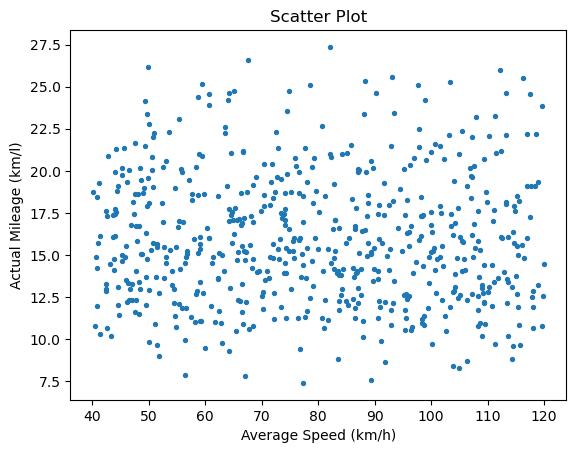

In [11]:
# =========================
# SCATTER
# =========================
plt.scatter(dataset["avg_speed_kmph"], dataset["actual_mileage_kmpl"], s=8)
plt.xlabel("Average Speed (km/h)")
plt.ylabel("Actual Mileage (km/l)")
plt.title("Scatter Plot")
plt.show()

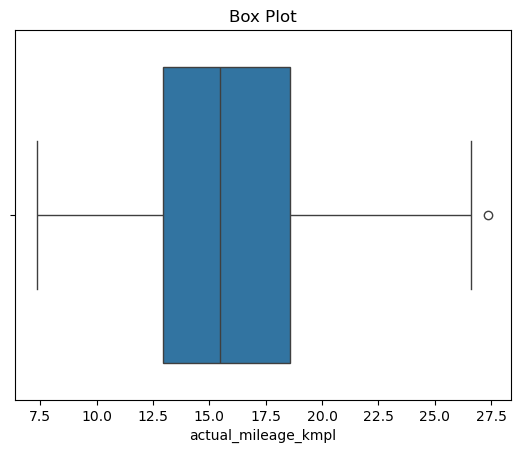

In [12]:
# =========================
# BOXPLOT
# =========================
sns.boxplot(x=dataset["actual_mileage_kmpl"])
plt.title("Box Plot")
plt.show()

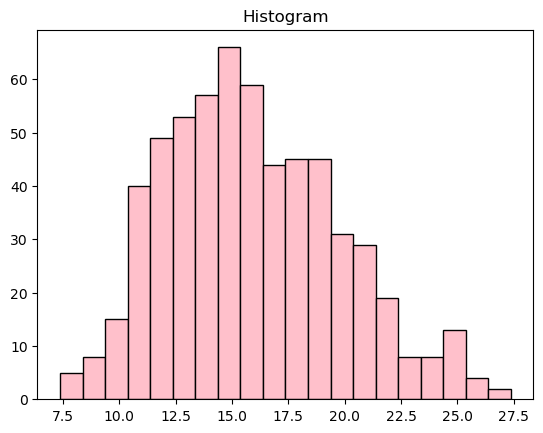

In [13]:
# =========================
# HISTOGRAM
# =========================
plt.hist(dataset["actual_mileage_kmpl"], bins=20, edgecolor="black", color="pink")
plt.title("Histogram")
plt.show()

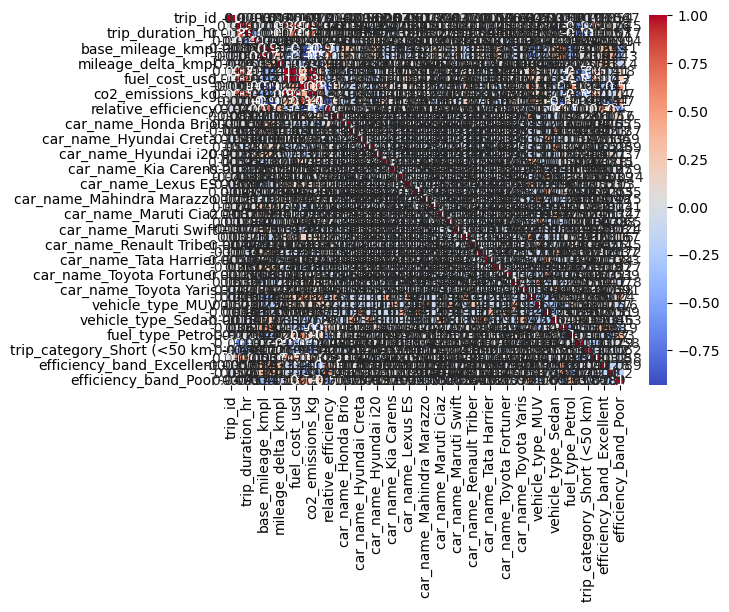

In [16]:
# =========================
# HEATMAP
# =========================
corr = dataset.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [17]:
# =========================
# PEARSON TEST
# =========================
clean_data = dataset[["avg_speed_kmph", "actual_mileage_kmpl"]].dropna()

pearson_corr, pearson_p = stats.pearsonr(
    clean_data["avg_speed_kmph"],
    clean_data["actual_mileage_kmpl"]
)

print(pearson_corr, pearson_p)

-0.025770900580227126 0.5286659067353509


In [18]:

# =========================
# SPEARMAN
# =========================
spearman_corr, spearman_p = stats.spearmanr(
    clean_data["avg_speed_kmph"],
    clean_data["actual_mileage_kmpl"]
)

print(spearman_corr, spearman_p)

-0.037811796493998344 0.3551764514396605


In [19]:
# =========================
# NORMALITY
# =========================
r, p = stats.shapiro(dataset["actual_mileage_kmpl"].dropna())

print(r, p)

0.9832419792586283 2.216937066775736e-06


In [20]:
# =========================
# T TEST
# =========================
stats.ttest_1samp(dataset["actual_mileage_kmpl"].dropna(), 0)

TtestResult(statistic=100.96869522118547, pvalue=0.0, df=599)

In [21]:
# =========================
# CLASSIFICATION
# =========================
data = pd.read_csv("cars_fuel_efficiency_clean.csv")

data_encoded = pd.get_dummies(data, drop_first=True)

X = data_encoded.drop(columns=['efficiency_band_Good', 'efficiency_band_Poor'])
y = data['efficiency_band']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [22]:
# LOGISTIC
logistic_model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
y_pred = cross_val_predict(logistic_model, X_scaled, y, cv=cv)

print(confusion_matrix(y, y_pred))
print(accuracy_score(y, y_pred))

[[319   0   8   4]
 [  0  44   0   0]
 [ 10   0 160   0]
 [ 18   0   0  37]]
0.9333333333333333


In [23]:
# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
y_pred = cross_val_predict(knn_model, X_scaled, y, cv=cv)

print(confusion_matrix(y, y_pred))
print(accuracy_score(y, y_pred))

[[282   0  45   4]
 [  8  12  24   0]
 [ 83   1  86   0]
 [ 36   0   0  19]]
0.665


In [24]:
# NAIVE BAYES
nb_model = GaussianNB()
y_pred = cross_val_predict(nb_model, X_scaled, y, cv=cv)

print(confusion_matrix(y, y_pred))
print(accuracy_score(y, y_pred))

[[108   0  41 182]
 [  0  34  10   0]
 [ 22   0 121  27]
 [  9   0   0  46]]
0.515


In [25]:
# DECISION TREE
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
y_pred = cross_val_predict(dt_model, X_scaled, y, cv=cv)

print(confusion_matrix(y, y_pred))
print(accuracy_score(y, y_pred))

[[330   0   0   1]
 [  0  44   0   0]
 [  0   0 170   0]
 [  0   0   0  55]]
0.9983333333333333


In [26]:
# COUNT TARGET
print(data['efficiency_band'].value_counts())

efficiency_band
Average      331
Good         170
Poor          55
Excellent     44
Name: count, dtype: int64


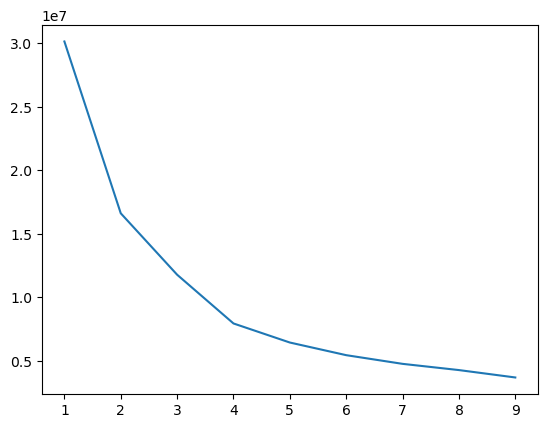

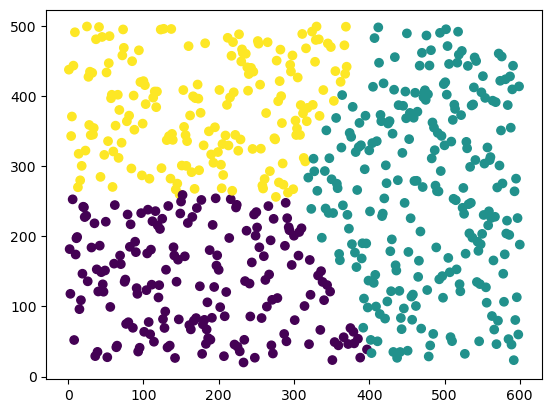

In [27]:
# =========================
# KMEANS
# =========================
dataset = pd.read_csv("cars_fuel_efficiency_clean.csv")

dataset = dataset.select_dtypes(include=[np.number])
dataset = dataset.fillna(dataset.mean())

X = dataset.copy()

wcss = []
for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
dataset["Cluster"] = kmeans.fit_predict(X)

plt.scatter(X.iloc[:,0], X.iloc[:,1], c=dataset["Cluster"])
plt.show()